Logit lens implementation for MolFormer with ablation capability, inspired by the blog post [“interpreting GPT: the logit lens”](https://www.lesswrong.com/posts/AcKRB8wDpdaN6v6ru/interpreting-gpt-the-logit-lens).

In [ ]:
# pkgs
import re
import torch
import torch.nn.functional as F
import polars as pl

from pathlib import Path
from tqdm.notebook import tqdm
from typing import Optional
from rdkit import Chem

from intermol.main.inference import (
    SAEInferenceConfig, SAEInferenceModule, SAEWithBaseModel
)
from intermol.interp.smiles_editor import enum_mask_smi

# defaults
LAYERS = [1, 3, 6, 9, 12]
DIRS = {layer: next(Path("..").glob(f"results_layer{layer}_*")) for layer in LAYERS}

OUTDIR = Path("../plots")

# utils
def get_kl_div(
    logits1: torch.Tensor,
    logits2: torch.Tensor,
    mask_pos: Optional[int] = None # special tokens are ignored
) -> torch.Tensor:
    if mask_pos is not None:
        x1 = logits1[:, mask_pos+1, :]
        x2 = logits2[:, mask_pos+1, :]
    else:
        x1, x2 = logits1, logits2
    return F.kl_div(
        F.log_softmax(x2, dim=-1),
        F.softmax(x1, dim=-1),
        reduction="batchmean"
    )

# core
def gen_logit_lens_data(
    module: SAEInferenceModule,
    smi: str,
    f: int | torch.IntTensor,
    value: float = 1,
    do_scale: bool = True,
    start: int = 0,
    end: Optional[int] = None,
    excl_token: Optional[re.Pattern] = None,
    out_kl_div: bool = False
) -> pl.DataFrame:
    # generate masked input
    masked = enum_mask_smi(smi, start, end, excl_token)

    output = {
        "smiles": [],
        "mask_pos": [],
        "mask_token": [],
        "layer": [],
        "logits": [],
        "probs": [],
        "tokens": []
    }
    if out_kl_div:
        output["kl_div_from_last"] = []

    for s, pos, tk in tqdm(masked, desc="Processing per masked SMILES..."):
        _, hs = module.ablate(smi=s, f=f, value=value, do_scale=do_scale)
        hs = torch.concat(hs)

        # skip embedding layer
        n_hs = hs.shape[0]
        logits_masked = module.get_logits(hs[1:])[:, pos+1, :]

        # get top tokens and probs
        probs = F.softmax(logits_masked, dim=-1)
        topk_probs, topk_ind = torch.topk(probs, k=1)
        topk_logits = logits_masked.gather(-1, topk_ind)

        topk_probs = topk_probs.cpu().squeeze().tolist()
        topk_logits = topk_logits.cpu().squeeze().tolist()
        topk_tks = module.tokenizer.convert_ids_to_tokens(topk_ind.squeeze())

        rep = int(n_hs-1)
        output["smiles"].extend([s] * rep)
        output["mask_pos"].extend([pos] * rep)
        output["mask_token"].extend([tk] * rep)

        output["layer"].extend(list(range(1, n_hs)))
        output["logits"].extend(topk_logits)
        output["probs"].extend(topk_probs)
        output["tokens"].extend(topk_tks)

        # kl_div
        if out_kl_div:
            last_logits = logits_masked[-1]
            kl_per_layer = [
                get_kl_div(
                    last_logits,
                    logits_masked[layer].unsqueeze(0),
                    mask_pos=None # already sliced
                ).item()
                for layer in range(n_hs - 1)
            ]
            output["kl_div_from_last"].extend(kl_per_layer)

    return pl.DataFrame(output)

In [ ]:
# cfgs
LAYER = 1
SAE_CFG = SAEInferenceConfig(
    layer_idx=LAYER,
    hidden_dim=3072,
    k=128,
    sae_pth=DIRS[LAYER] / "norm" / "norm-sae_state-dict_273908s_12165077t.pt"
)

# init module
module = SAEWithBaseModel(SAE_CFG)

In [ ]:
# cfgs
FEATURE = 0 # or torch.IntTensor(); ignored when no ablation is performed
VALUE = 1
DO_SCALE = True

SMILES = "c1ccccc1"
MAX_LEN = 0
EXCL_TOKEN = None
OUT_KL_DIV = True

# main
## canonicalize
SMILES = Chem.MolToSmiles(Chem.MolFromSmiles(SMILES), canonical=True)

df = gen_logit_lens_data(
    module=module,
    smi=SMILES,
    f=FEATURE,
    value=VALUE,
    do_scale=DO_SCALE,
    max_len=MAX_LEN,
    excl_token=EXCL_TOKEN,
    out_kl_div=OUT_KL_DIV
)

# to csv
#df.write_csv(OUTDIR / f"logit_lens_{SMILES}.csv")

Processing per masked SMILES...:   0%|          | 0/8 [00:00<?, ?it/s]

(array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5,
        11.5]),
 [Text(0, 0.5, 'L12'),
  Text(0, 1.5, 'L11'),
  Text(0, 2.5, 'L10'),
  Text(0, 3.5, 'L9'),
  Text(0, 4.5, 'L8'),
  Text(0, 5.5, 'L7'),
  Text(0, 6.5, 'L6'),
  Text(0, 7.5, 'L5'),
  Text(0, 8.5, 'L4'),
  Text(0, 9.5, 'L3'),
  Text(0, 10.5, 'L2'),
  Text(0, 11.5, 'L1')])

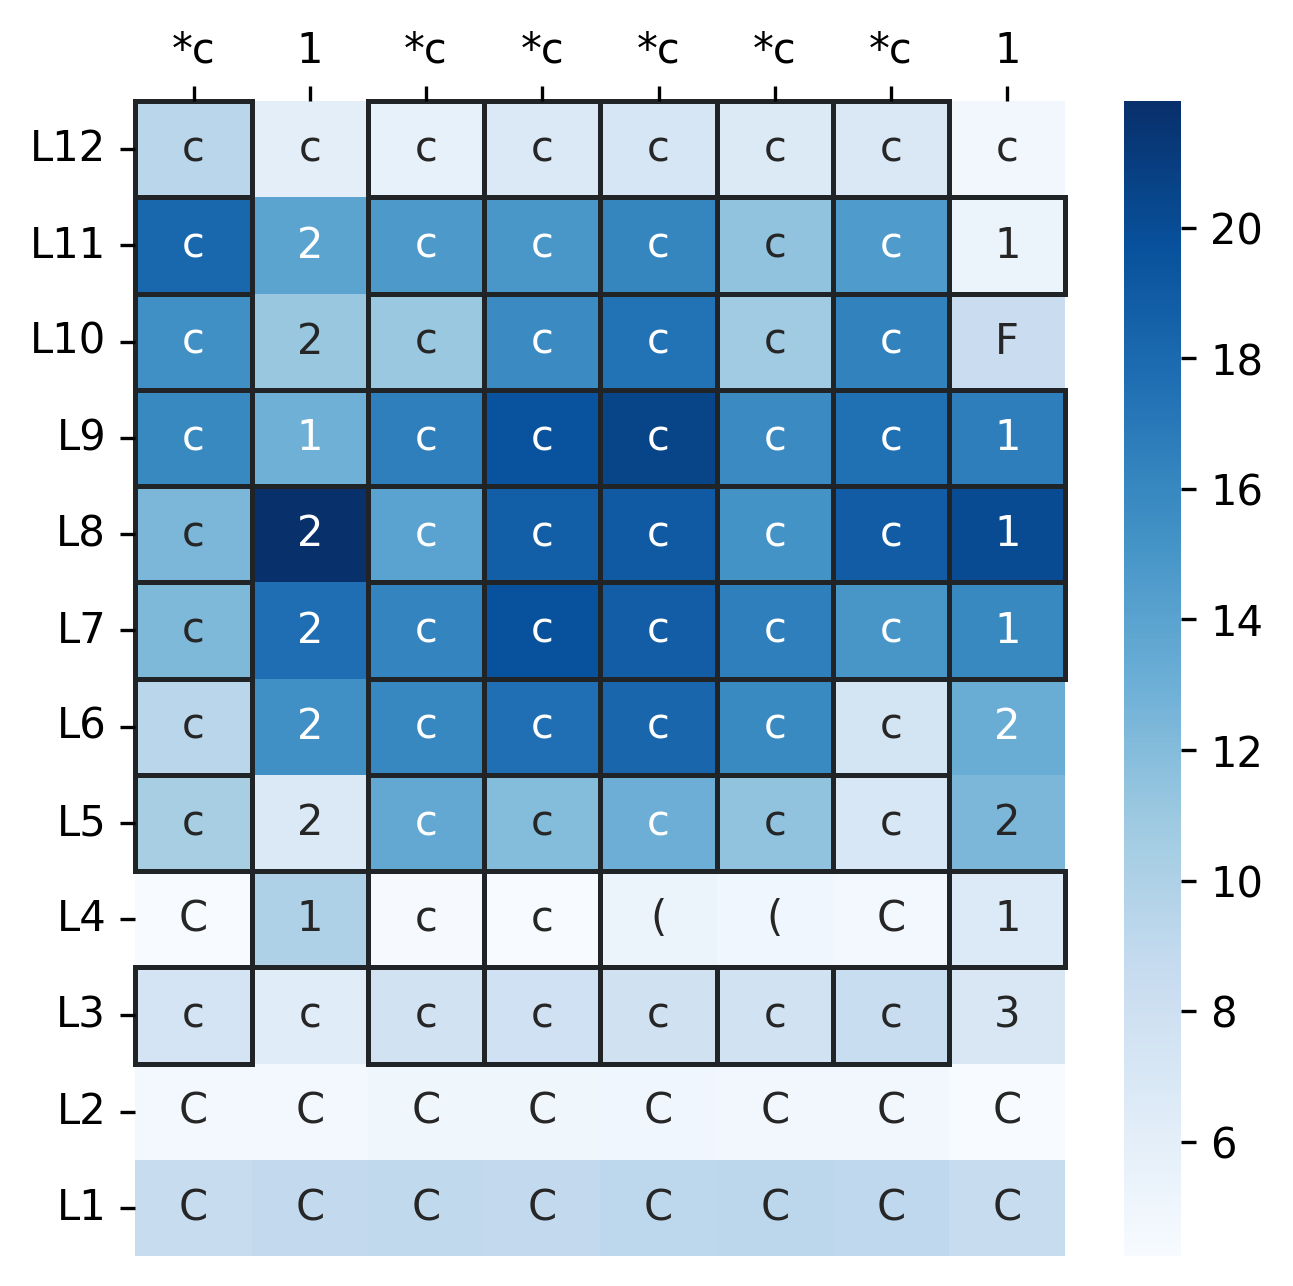

In [ ]:
# vis
## pkgs
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle

## data
df_pd = (
    df
    .with_columns(
        pl.concat_str([pl.lit("L"), pl.col("layer")]).alias("layer")
    )
    .to_pandas()
)

### data for plotting heatmap
hm_df = (
    df_pd
    .pivot(columns="mask_pos", index="layer", values="logits")
    .sort_values(
        "layer", key=lambda x: x.str.extract(r'(\d+)')[0].astype(int), ascending=False
    )
)
hm_df_annot = (
    df_pd
    .pivot(columns="mask_pos", index="layer", values="tokens")
    .sort_values(
        "layer", key=lambda x: x.str.extract(r'(\d+)')[0].astype(int), ascending=False
    )
)
hm_df_xticklabels = (
    df
    .filter(pl.col("layer") == 12)
    .with_columns(
        pl.when(pl.col("mask_token") == pl.col("tokens"))
        .then(pl.lit("*") + pl.col("mask_token"))
        .otherwise(pl.col("mask_token"))
        .alias("mask_token")
    )
    .unique(["mask_pos", "mask_token"], maintain_order=True)["mask_token"]
    .to_list()
)

## plot
fig, ax = plt.subplots(figsize=(5, 5), dpi=300)

sns.heatmap(
    hm_df,
    cmap="Blues",
    annot=hm_df_annot,
    fmt="",
    ax=ax
)

ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
ax.set(
    xlabel=None,
    xticklabels=hm_df_xticklabels,
    ylabel=None
)

### highlight matching tokens
n_rows, n_cols = hm_df_annot.shape
for col in range(n_cols):
    tk = hm_df_xticklabels[col].lstrip("*")
    for row in range(n_rows):
        if hm_df_annot.iloc[row, col] == tk:
            ax.add_patch(
                Rectangle(
                    (col, row),
                    1, 1,
                    fill=False,
                    edgecolor='#212427',
                    lw=1.2,
                    clip_on=False
                )
            )

plt.yticks(rotation=0)

## to svg
#fig.savefig(OUTDIR / f"logit_lens_{SMILES}.svg", dpi=300, bbox_inches="tight")